In [1]:
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np

def generate_subsets(Nt, L):
    return list(combinations(range(Nt), L))

def generate_sm_symbols(L, mod_type='PSK', M=4):

    constellation = generate_constellation(mod_type,M)
    X = []

    for q in range(L):
        for s in constellation:
            x = np.zeros(L, dtype=complex)
            x[q] = s
            X.append(x)
    return np.array(X)

def generate_constellation(mod_type, M):

    mod_type = mod_type.upper()

    if mod_type == 'PSK':

        phase_offset = np.pi / M
        symbols = np.exp(1j * (2*np.pi*np.arange(M)/M + phase_offset))
        symbols = symbols / np.sqrt(np.mean(np.abs(symbols)**2))
        
        return np.round(symbols,5)

    elif mod_type == 'QAM':

        m_side = int(np.sqrt(M))
        
        if m_side**2 != M:
            raise ValueError("For QAM, M must be a perfect square.")

        levels = np.arange(-(m_side - 1),m_side,2)
        xv, yv = np.meshgrid(levels, levels)
        symbols = xv.flatten() + 1j*yv.flatten()
        symbols = symbols / np.sqrt(np.mean(np.abs(symbols)**2))

        return np.round(symbols,5)

    else:

        raise ValueError("Use 'PSK' or 'QAM'")

def compute_dmin(Hk, X_set):
    dmin = np.inf
    for i in range(len(X_set)):
        for j in range(i+1, len(X_set)):
            diff = Hk @ (X_set[i] - X_set[j])
            dist = np.linalg.norm(diff)**2
            if dist < dmin:
                dmin = dist
    return dmin

def symbol_to_bits(symbol, constellation):
    
    M = len(constellation)
    bits_per_symbol = int(np.log2(M))
    idx = np.argmin(np.abs(symbol - constellation))
    bits = np.binary_repr(idx,width=bits_per_symbol)
    
    return np.array([int(b) for b in bits])
        
def detect_symbol(Hk, y, symbols):

    best_metric = np.inf
    best_q = 0
    best_s = symbols[0]

    for q in range(Hk.shape[1]):

        h_q = Hk[:, q]

        # matched filter output
        r_q = (h_q.conj().T @ y) / (np.linalg.norm(h_q)**2 + 1e-12)

        for s in symbols:

            metric = metric = np.abs(r_q - s)**2

            if metric < best_metric:

                best_metric = metric
                best_q = q
                best_s = s

    return best_q, best_s

Nr = 2      
Nt = 8      
M = 2000
M_APM = 4
mod_type = 'PSK'
symbols = generate_constellation(mod_type, M_APM)

H_dataset = (np.random.randn(M, Nr, Nt) + 
             1j * np.random.randn(M, Nr, Nt)) / np.sqrt(2)

X_cfvg = np.abs(H_dataset).reshape(M, -1)

H_herm = np.conj(np.transpose(H_dataset, (0, 2, 1)))
F = np.matmul(H_herm, H_dataset)

X_jfvg = np.abs(F).reshape(M, -1)

cfvg_mean = np.mean(X_cfvg, axis=1, keepdims=True)
cfvg_max  = np.max(X_cfvg, axis=1, keepdims=True)
cfvg_min  = np.min(X_cfvg, axis=1, keepdims=True)

X_cfvg_norm = (X_cfvg - cfvg_mean) / (cfvg_max - cfvg_min)

jfvg_mean = np.mean(X_jfvg, axis=1, keepdims=True)
jfvg_max  = np.max(X_jfvg, axis=1, keepdims=True)
jfvg_min  = np.min(X_jfvg, axis=1, keepdims=True)

X_jfvg_norm = (X_jfvg - jfvg_mean) / (jfvg_max - jfvg_min)

L = 2
subsets = generate_subsets(Nt, L)
X_set = generate_sm_symbols(L,mod_type,M_APM)

y_labels = []

for m in range(H_dataset.shape[0]):
    H = H_dataset[m]
    
    dmins = []
    
    for subset in subsets:
        Hk = H[:, subset]   # select columns
        d = compute_dmin(Hk, X_set)
        dmins.append(d)
    
    label = np.argmax(dmins)
    y_labels.append(label)

y_labels = np.array(y_labels) 

perm = np.random.permutation(len(X_jfvg_norm))
X_features = X_jfvg_norm[perm] # Change to CFVG if needed
y_labels    = y_labels[perm]

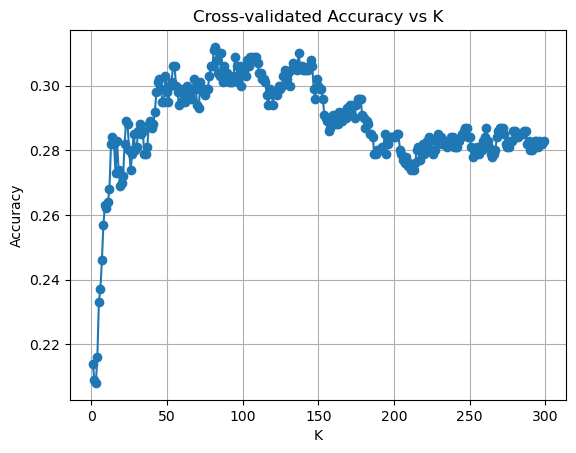

Best K: 82


In [7]:
def euclidean_distance(a, b):
    return np.sum((a - b)**2)

def knn_predict_one(X_train, y_train, x_new, K):

    distances = np.sum((X_train - x_new)**2, axis=1)

    nn_idx = np.argsort(distances)[:K]

    nn_labels = y_train[nn_idx]

    values, counts = np.unique(nn_labels, return_counts=True)
    return values[np.argmax(counts)]

def knn_predict(X_train, y_train, X_test, K):
    y_pred = []
    for x in X_test:
        y_pred.append(knn_predict_one(X_train, y_train, x, K))
    return np.array(y_pred)

def find_best_K_cv(X, y, num_splits=5):
    N = len(X)
    
    max_K = min(300,N//5)
    K_range = list(range(1, max_K))
    
    acc_matrix = np.zeros((len(K_range), num_splits))
    
    for split_id in range(num_splits):
        perm = np.random.permutation(N)
        X_shuff = X[perm]
        y_shuff = y[perm]
        
        split = int(0.9 * N)
        X_train, X_val = X_shuff[:split], X_shuff[split:]
        y_train, y_val = y_shuff[:split], y_shuff[split:]
        
        for i, K in enumerate(K_range):
            y_pred = knn_predict(X_train, y_train, X_val, K)
            acc = np.mean(y_pred == y_val)
            acc_matrix[i, split_id] = acc
    
    avg_acc = np.mean(acc_matrix, axis=1)
    
    best_idx = np.argmax(avg_acc)
    best_K = K_range[best_idx]
    
    return best_K, avg_acc, K_range

split = int(0.9 * len(X_features))
max_K = len(X_features)//5

X_train = X_features[:split]
y_train = y_labels[:split]

X_val = X_features[split:]
y_val = y_labels[split:]

best_K, avg_acc, K_range = find_best_K_cv(X_features, y_labels)

plt.plot(K_range, avg_acc, marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Cross-validated Accuracy vs K')
plt.grid()
plt.show()

print("Best K:", best_K)

BER: [0.2521333333333334, 0.11966666666666667, 0.04616666666666666, 0.014833333333333332, 0.006199999999999999]


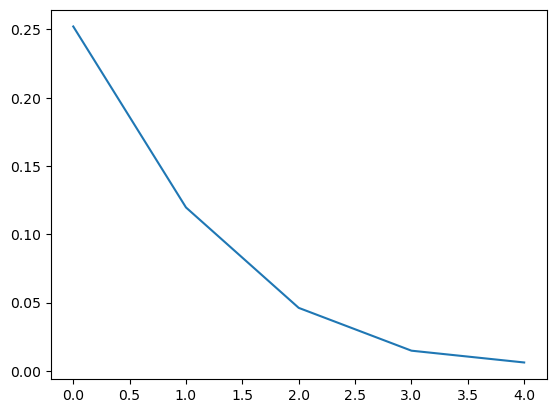

In [9]:
SNR_dB_range = np.arange(0, 20, 4)
BER_knn = []

num_trials = 10000
#---------------
total_bits = int(np.log2(L) +np.log2(M_APM))

for snr_db in SNR_dB_range:
    
    snr_linear = 10**(snr_db/10)
    noise_var = 1 / snr_linear
    err_avg = []
    
    for _ in range(num_trials):
        
        # Channel
        H = (np.random.randn(Nr, Nt) + 1j*np.random.randn(Nr, Nt)) / np.sqrt(2)
        
        F = H.conj().T @ H
        f = np.abs(F).flatten()
        
        f_mean = np.mean(f)
        f_max  = np.max(f)
        f_min  = np.min(f)
        f = (f - f_mean) / (f_max - f_min)
        
        pred_label = knn_predict_one(X_train, y_train, f, best_K)
        S_u = subsets[pred_label]
        
        e_l = np.random.randint(0, L)
        ta = S_u[e_l]
        s_l = np.random.choice(symbols)
        
        x = np.zeros(Nt, dtype=complex)
        x[ta] = s_l
        
        noise = np.sqrt(noise_var/2) * (np.random.randn(Nr) + 1j*np.random.randn(Nr))
        y = H @ x + noise

        Hk = H[:, S_u]
        u_hat, s_hat = detect_symbol(Hk, y, symbols)

        index_bits = int(np.log2(L))
        tx_ta_bits = np.array(list(np.binary_repr(e_l, width=index_bits)),dtype=int)
        rx_ta_bits = np.array(list(np.binary_repr(u_hat, width=index_bits)),dtype=int)
        tx_apm_bits = symbol_to_bits(s_l,symbols)
        rx_apm_bits = symbol_to_bits(s_hat,symbols)
        tx_bits = np.concatenate([tx_ta_bits, tx_apm_bits])
        rx_bits = np.concatenate([rx_ta_bits, rx_apm_bits])
        errors = np.sum(tx_bits != rx_bits)
        err_avg.append(errors / total_bits)

    BER_knn.append (np.mean(err_avg))

print("BER:", BER_knn)

plt.plot(BER_knn)

Conventional SM BER: [0.410225, 0.2975, 0.1682, 0.073525, 0.02605]


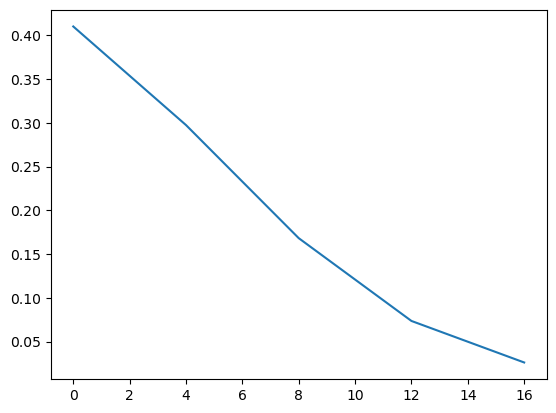

In [11]:
def antenna_to_bits(idx, Nt):

    bits_per_antenna = int(np.log2(Nt))
    bits = np.binary_repr(idx,width=bits_per_antenna)
    
    return np.array([int(b) for b in bits])

SNR_dB_range = np.arange(0, 20, 4)
BER_sm = []

num_trials = 10000
total_bits = int(np.log2(Nt) +np.log2(M_APM))

for snr_db in SNR_dB_range:
    
    snr_linear = 10**(snr_db/10)
    noise_var = 1 / snr_linear
    err_avg = []
    
    for _ in range(num_trials):
        
        # Channel
        H = (np.random.randn(Nr, Nt) + 1j*np.random.randn(Nr, Nt)) / np.sqrt(2)
        
        e_l = np.random.randint(0, Nt)
        s_l = np.random.choice(symbols)
        
        x = np.zeros(Nt, dtype=complex)
        x[e_l] = s_l
        
        noise = np.sqrt(noise_var/2) * (np.random.randn(Nr) + 1j*np.random.randn(Nr))
        y = H @ x + noise
        
        u_hat, s_hat = detect_symbol(H, y, symbols)

        
        tx_ta_bits = antenna_to_bits(e_l,Nt)
        rx_ta_bits = antenna_to_bits(u_hat,Nt)
        tx_apm_bits = symbol_to_bits(s_l,symbols)
        rx_apm_bits = symbol_to_bits(s_hat,symbols)
        tx_bits = np.concatenate([tx_ta_bits, tx_apm_bits])
        rx_bits = np.concatenate([rx_ta_bits, rx_apm_bits])
        errors = np.sum(tx_bits != rx_bits)
        err_avg.append(errors / total_bits)
    
    BER_sm.append(np.mean(err_avg))

print("Conventional SM BER:", BER_sm)

plt.plot(SNR_dB_range, BER_sm)

In [13]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
U = len(subsets)

Y_svm = np.zeros((U,M),dtype=int)
svm_models = []
best_params = []

for r in range(U):
    for i in range(M):
        if y_labels[i] == r:
            Y_svm[r, i] = 1
        else:
            Y_svm[r, i] = -1 

for r in range(U):
    param_grid = {'C': [0.1, 1, 10],'gamma': [0.01, 0.1, 1]}
    svm_model = SVC(kernel='rbf', probability=False)
    grid = GridSearchCV(svm_model,param_grid,cv=3,scoring='accuracy',verbose=1)
    grid.fit(X_features, Y_svm[r,:])
    best_params.append(grid.best_params_)
    svm_models.append(grid.best_estimator_)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates

BER: [0.2572333333333333, 0.09863333333333332, 0.024333333333333332, 0.004633333333333333, 0.0011666666666666665]


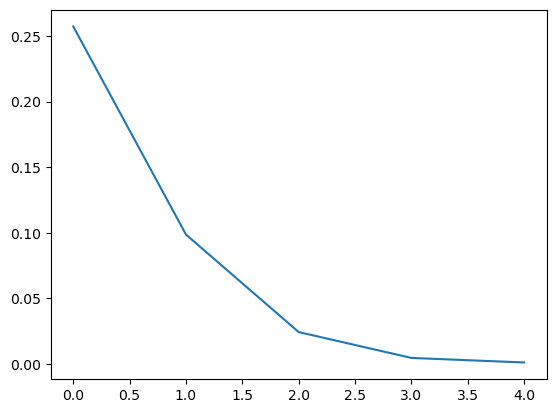

In [25]:
SNR_dB_range = np.arange(0, 20, 4)
BER_svm = []

num_trials = 10000
total_bits = int(np.log2(L) +np.log2(M_APM))

for snr_db in SNR_dB_range:
    
    snr_linear = 10**(snr_db/10)
    noise_var = 1 / snr_linear
    err_avg = []
    
    for _ in range(num_trials):
        
        # Channel
        H = (np.random.randn(Nr, Nt) + 1j*np.random.randn(Nr, Nt)) / np.sqrt(2)
        
        F = H.conj().T @ H
        f = np.abs(F).flatten()
        
        f_mean = np.mean(f)
        f_max  = np.max(f)
        f_min  = np.min(f)
        f = (f - f_mean) / (f_max - f_min)
        
        scores = []

        for r in range(U):

            score = svm_models[r].decision_function(f.reshape(1, -1))[0]
            scores.append(score)

        pred_label = np.argmax(scores)
        S_u = subsets[pred_label]
        
        e_l = np.random.randint(0, L)
        ta = S_u[e_l]
        s_l = np.random.choice(symbols)
        
        x = np.zeros(Nt, dtype=complex)
        x[ta] = s_l
        
        noise = np.sqrt(noise_var/2) * (np.random.randn(Nr) + 1j*np.random.randn(Nr))
        y = H @ x + noise

        Hk = H[:, S_u]
        u_hat, s_hat = detect_symbol(Hk, y, symbols)
        
        index_bits = int(np.log2(L))
        tx_ta_bits = np.array(list(np.binary_repr(e_l, width=index_bits)),dtype=int)
        rx_ta_bits = np.array(list(np.binary_repr(u_hat, width=index_bits)),dtype=int)
        tx_apm_bits = symbol_to_bits(s_l, symbols)
        rx_apm_bits = symbol_to_bits(s_hat, symbols)
        tx_bits = np.concatenate([tx_ta_bits, tx_apm_bits])
        rx_bits = np.concatenate([rx_ta_bits, rx_apm_bits])
        errors = np.sum(tx_bits != rx_bits)
        err_avg.append(errors / total_bits)

    BER_svm.append (np.mean(err_avg))

print("BER:", BER_svm)

plt.plot(BER_svm)

In [39]:
U = len(subsets)

Y_onehot = np.zeros((M, U))

for i in range(M):
    Y_onehot[i, y_labels[i]] = 1

Df = Nt**2

num_epochs = 10000
mu = 0.01
batch_size = 64
input_dim  = Df
hidden1    = 2*Df
hidden2    = Df
hidden3    = Df
output_dim = U

W1 = np.random.randn(input_dim, hidden1) * np.sqrt(2/input_dim)
b1 = np.zeros((1, hidden1))

W2 = np.random.randn(hidden1, hidden2) * np.sqrt(2/hidden1)
b2 = np.zeros((1, hidden2))

W3 = np.random.randn(hidden2, hidden3) * np.sqrt(2/hidden2)
b3 = np.zeros((1, hidden3))

W4 = np.random.randn(hidden3, output_dim) * np.sqrt(2/hidden3)
b4 = np.zeros((1, output_dim))

def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def forward(X):

    z1 = X @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = relu(z2)

    z3 = a2 @ W3 + b3
    a3 = relu(z3)

    z4 = a3 @ W4 + b4
    y_hat = softmax(z4)

    cache = (z1,a1,z2,a2,z3,a3,z4,y_hat)

    return y_hat, cache

def cross_entropy(y_true, y_pred):
    eps = 1e-12
    return -np.mean(np.sum(y_true * np.log(y_pred + eps),axis=1))

prev_grad_norm_sq = None

E_W1 = np.zeros_like(W1)
E_b1 = np.zeros_like(b1)

E_W2 = np.zeros_like(W2)
E_b2 = np.zeros_like(b2)

E_W3 = np.zeros_like(W3)
E_b3 = np.zeros_like(b3)

E_W4 = np.zeros_like(W4)
E_b4 = np.zeros_like(b4)

for epoch in range(num_epochs):

    idx = np.random.choice(M, batch_size, replace=False)

    X_batch = X_features[idx]
    Y_batch = Y_onehot[idx]

    # forward
    y_hat, cache = forward(X_batch)

    # loss
    loss = cross_entropy(Y_batch, y_hat)

    # backprop
    z1,a1,z2,a2,z3,a3,z4,y_hat = cache

    M_batch = X_batch.shape[0]

    dz4 = (y_hat - Y_batch) / M_batch
    dW4 = a3.T @ dz4
    db4 = np.sum(dz4, axis=0, keepdims=True)

    da3 = dz4 @ W4.T
    dz3 = da3 * relu_deriv(z3)
    dW3 = a2.T @ dz3
    db3 = np.sum(dz3, axis=0, keepdims=True)

    da2 = dz3 @ W3.T
    dz2 = da2 * relu_deriv(z2)
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    da1 = dz2 @ W2.T
    dz1 = da1 * relu_deriv(z1)
    dW1 = X_batch.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    grad_norm_sq = (np.sum(dW1**2) + np.sum(db1**2) + np.sum(dW2**2) + np.sum(db2**2) + np.sum(dW3**2) + np.sum(db3**2) + np.sum(dW4**2) + np.sum(db4**2))

    if prev_grad_norm_sq is None:
        phi = 0
    else:
        phi = grad_norm_sq / (prev_grad_norm_sq + 1e-12)
        phi = np.clip(phi, 0, 1)

    E_W1 = -dW1 + phi*E_W1
    E_b1 = -db1 + phi*E_b1
    E_W2 = -dW2 + phi*E_W2
    E_b2 = -db2 + phi*E_b2
    E_W3 = -dW3 + phi*E_W3
    E_b3 = -db3 + phi*E_b3
    E_W4 = -dW4 + phi*E_W4
    E_b4 = -db4 + phi*E_b4

    E_norm = np.sqrt(np.sum(E_W1**2) + np.sum(E_b1**2) + np.sum(E_W2**2) + np.sum(E_b2**2) + np.sum(E_W3**2) + np.sum(E_b3**2) + np.sum(E_W4**2) + np.sum(E_b4**2))

    W1 += mu * E_W1 / (E_norm + 1e-12)
    b1 += mu * E_b1 / (E_norm + 1e-12)

    W2 += mu * E_W2 / (E_norm + 1e-12)
    b2 += mu * E_b2 / (E_norm + 1e-12)

    W3 += mu * E_W3 / (E_norm + 1e-12)
    b3 += mu * E_b3 / (E_norm + 1e-12)

    W4 += mu * E_W4 / (E_norm + 1e-12)
    b4 += mu * E_b4 / (E_norm + 1e-12)

    prev_grad_norm_sq = grad_norm_sq

    if epoch % 50 == 0:
        pred = np.argmax(y_hat, axis=1)
        true = np.argmax(Y_batch, axis=1)
        acc = np.mean(pred == true)
        print(f"Epoch {epoch}, " f"Loss = {loss:.6f}, " f"Acc = {acc:.4f}")

probs_full, _ = forward(X_features)

pred_full = np.argmax(probs_full, axis=1)

train_acc = np.mean(pred_full == y_labels)

print("Full Training Accuracy:", train_acc)

def predict_dnn(X):

    probs, _ = forward(X)
    pred_label = np.argmax(probs, axis=1)[0]
    return pred_label

Epoch 0, Loss = 3.358417, Acc = 0.0469
Epoch 50, Loss = 3.312409, Acc = 0.0156
Epoch 100, Loss = 3.226941, Acc = 0.0625
Epoch 150, Loss = 3.154786, Acc = 0.1562
Epoch 200, Loss = 2.986657, Acc = 0.2812
Epoch 250, Loss = 3.032515, Acc = 0.2188
Epoch 300, Loss = 2.789241, Acc = 0.2188
Epoch 350, Loss = 2.686520, Acc = 0.2500
Epoch 400, Loss = 2.582940, Acc = 0.2500
Epoch 450, Loss = 2.387808, Acc = 0.2969
Epoch 500, Loss = 2.436849, Acc = 0.2031
Epoch 550, Loss = 2.295813, Acc = 0.3438
Epoch 600, Loss = 1.939444, Acc = 0.5312
Epoch 650, Loss = 2.049104, Acc = 0.3750
Epoch 700, Loss = 2.062249, Acc = 0.3438
Epoch 750, Loss = 1.934831, Acc = 0.4531
Epoch 800, Loss = 1.660786, Acc = 0.5156
Epoch 850, Loss = 1.745190, Acc = 0.5000
Epoch 900, Loss = 1.755496, Acc = 0.4844
Epoch 950, Loss = 1.623372, Acc = 0.5156
Epoch 1000, Loss = 1.611291, Acc = 0.5469
Epoch 1050, Loss = 1.723348, Acc = 0.4531
Epoch 1100, Loss = 1.634180, Acc = 0.5312
Epoch 1150, Loss = 1.529266, Acc = 0.5469
Epoch 1200, Los

BER: [0.2481, 0.09623333333333332, 0.022166666666666664, 0.005566666666666667, 0.0014333333333333331]


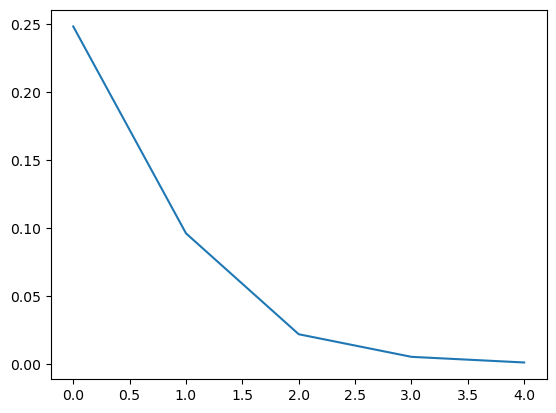

In [41]:
SNR_dB_range = np.arange(0, 20, 4)
BER_dnn = []

num_trials = 10000
total_bits = int(np.log2(L) +np.log2(M_APM))

for snr_db in SNR_dB_range:
    
    snr_linear = 10**(snr_db/10)
    noise_var = 1 / snr_linear
    err_avg = []
    
    for _ in range(num_trials):
        
        # Channel
        H = (np.random.randn(Nr, Nt) + 1j*np.random.randn(Nr, Nt)) / np.sqrt(2)
        
        F = H.conj().T @ H
        f = np.abs(F).flatten()
        
        f_mean = np.mean(f)
        f_max  = np.max(f)
        f_min  = np.min(f)
        f = (f - f_mean) / (f_max - f_min)

        pred_label = predict_dnn(f)
        S_u = subsets[pred_label]
        
        e_l = np.random.randint(0, L)
        ta = S_u[e_l]
        s_l = np.random.choice(symbols)
        
        x = np.zeros(Nt, dtype=complex)
        x[ta] = s_l
        
        noise = np.sqrt(noise_var/2) * (np.random.randn(Nr) + 1j*np.random.randn(Nr))
        y = H @ x + noise

        Hk = H[:, S_u]
        u_hat, s_hat = detect_symbol(Hk, y, symbols)
        
        index_bits = int(np.log2(L))
        tx_ta_bits = np.array(list(np.binary_repr(e_l, width=index_bits)),dtype=int)
        rx_ta_bits = np.array(list(np.binary_repr(u_hat, width=index_bits)),dtype=int)
        tx_apm_bits = symbol_to_bits(s_l, symbols)
        rx_apm_bits = symbol_to_bits(s_hat, symbols)
        tx_bits = np.concatenate([tx_ta_bits, tx_apm_bits])
        rx_bits = np.concatenate([rx_ta_bits, rx_apm_bits])
        errors = np.sum(tx_bits != rx_bits)
        err_avg.append(errors / total_bits)

    BER_dnn.append (np.mean(err_avg))

print("BER:", BER_dnn)

plt.plot(BER_dnn)

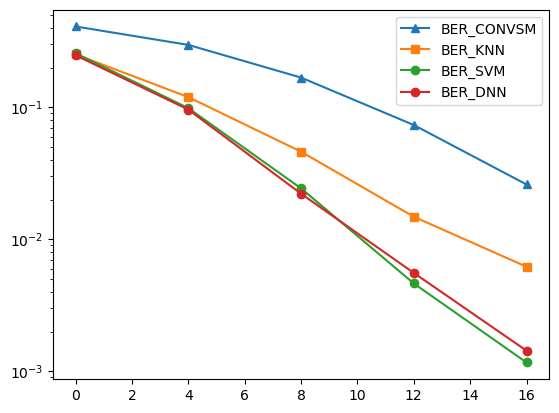

In [43]:
import matplotlib.pyplot as plt

plt.semilogy(SNR_dB_range, BER_sm, '^-', label='BER_CONVSM')
plt.semilogy(SNR_dB_range, BER_knn, 's-', label='BER_KNN')
plt.semilogy(SNR_dB_range, BER_svm, 'o-', label='BER_SVM')
plt.semilogy(SNR_dB_range, BER_dnn, 'o-', label='BER_DNN')

plt.legend(loc='best')
plt.show()

8
